In [ ]:
import pandas as pd
import numpy as np
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [ ]:
df = pd.read_csv("/content/Tasks WDA - RAW DATA.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12740 entries, 0 to 12739
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_id           12740 non-null  object 
 1   job_title        12740 non-null  object 
 2   experience_min   11887 non-null  float64
 3   experience_max   10426 non-null  float64
 4   salary_min       7175 non-null   float64
 5   salary_max       7175 non-null   float64
 6   salary_string    12740 non-null  object 
 7   location         12740 non-null  object 
 8   address          9967 non-null   object 
 9   job_active_date  12740 non-null  object 
 10  link             12740 non-null  object 
 11  job_description  12696 non-null  object 
 12  requirements     12705 non-null  object 
dtypes: float64(4), object(9)
memory usage: 1.3+ MB


In [ ]:
print(df.duplicated().sum())

10155


In [ ]:
df.isnull().sum()

,0
job_id,0
job_title,0
experience_min,853
experience_max,2314
salary_min,5565
salary_max,5565
salary_string,0
location,0
address,2773
job_active_date,0


In [ ]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


In [ ]:
required_cols = [
    'experience_min',
    'experience_max',
    'salary_min',
    'salary_max',
    'address'
]
df = df.dropna(subset=required_cols)
print("Remaining rows:", len(df))
print("Missing summary:\n", df.isnull().sum())

Remaining rows: 926
Missing summary:
 job_id             0
job_title          0
experience_min     0
experience_max     0
salary_min         0
salary_max         0
salary_string      0
location           0
address            0
job_active_date    0
link               0
job_description    1
requirements       0
dtype: int64


In [ ]:
df.shape

(926, 13)

In [ ]:
df['salary_min'] = pd.to_numeric(df['salary_min'], errors='coerce')
df['salary_max'] = pd.to_numeric(df['salary_max'], errors='coerce')

In [ ]:
df['experience_min'] = pd.to_numeric(df['experience_min'], errors='coerce')
df['experience_max'] = pd.to_numeric(df['experience_max'], errors='coerce')

In [ ]:
invalid_salary = df[df['salary_min'] > df['salary_max']]
invalid_exp = df[df['experience_min'] > df['experience_max']]

print("Invalid salary:", len(invalid_salary))
print("Invalid experience:", len(invalid_exp))

Invalid salary: 19
Invalid experience: 69


In [ ]:
before = len(df)

df = df[
    (df['salary_min'] <= df['salary_max']) &
    (df['experience_min'] <= df['experience_max'])
]

after = len(df)

print("Rows removed:", before - after)
print("Remaining rows:", after)

Rows removed: 83
Remaining rows: 843


In [ ]:
df['salary_avg'] = (df['salary_min'] + df['salary_max']) / 2

In [ ]:
df["experience_avg"] = (df["experience_min"] + df["experience_max"]) / 2

In [ ]:
def exp_group(x):

    if pd.isna(x):
        return "Unknown"

    elif x == 0:
        return "Intern"

    elif x <= 1:
        return "Fresher"

    elif x <= 2:
        return "Junior"

    elif x <= 4:
        return "Senior"

    else:
        return "Manager"


df["job_level"] = df["experience_avg"].apply(exp_group)

In [ ]:
df["job_level"].value_counts().sort_index()

,count
job_level,
Fresher,18
Intern,39
Junior,244
Manager,116
Senior,426


In [ ]:
level_summary = df.groupby("job_level").agg({
    "job_id": "count",
    "salary_min": "mean",
    "salary_max": "mean",
    "salary_avg": "mean",
    "experience_min": "mean",
    "experience_max": "mean",
    "experience_avg": "mean"
}).rename(columns={"job_id": "job_count"}).reset_index()
level_summary = level_summary.round(2)
level_summary

,job_level,job_count,salary_min,salary_max,salary_avg,experience_min,experience_max,experience_avg
0,Fresher,18,9694444.44,12916666.67,11305555.56,0.00,1.11,0.56
1,Intern,39,8487189.74,12025653.85,10256421.79,0.00,0.00,0.00
2,Junior,244,10735655.74,14372540.98,12554098.36,1.00,2.34,1.67
3,Manager,116,21827608.62,30258670.69,26043139.66,4.68,8.74,6.71
4,Senior,426,15089205.63,20528176.29,17808690.96,2.31,4.20,3.25


In [ ]:
df['job_active_date'] = pd.to_datetime(df['job_active_date'], format='ISO8601')

df['year'] = df['job_active_date'].dt.year
df['month'] = df['job_active_date'].dt.month
df['quarter'] = df['job_active_date'].dt.quarter
df['day'] = df['job_active_date'].dt.day

In [ ]:
df["location"].unique()

array(['Ho Chi Minh', 'Binh Duong', 'Ba Ria-VT', 'Ha Noi', 'Dong Nai',
       'Ho Chi Minh, Binh Duong', 'Long An', 'Ho Chi Minh, Ha Noi',
       'Dong Nai, Ba Ria-VT', 'Dong Nai, Ho Chi Minh',
       'Ha Noi, Ho Chi Minh', 'Ha Noi, Hai Phong', 'Ha Nam', 'Khanh Hoa',
       'Can Tho', 'Tay Ninh, Dong Nai, Binh Duong', 'Kien Giang',
       'Hai Phong', 'Hung Yen', 'Lam Dong', 'Bac Ninh', 'Da Nang',
       'Hai Duong', 'Quang Ninh', 'Binh Thuan', 'Ha Noi, Bac Ninh',
       'Dong Thap', 'An Giang', 'Ho Chi Minh, Hoa Binh',
       'Hung Yen, Ha Noi', 'Tay Ninh', 'Ca Mau',
       'Binh Duong, Dong Thap, Vinh Long', 'Nghe An',
       'Ho Chi Minh, Dong Thap, Ha Noi', 'Tien Giang',
       'Hai Phong, Da Nang, Dong Thap', 'Ho Chi Minh, Dong Nai',
       'Quang Ngai', 'Ho Chi Minh, Long An', 'Phu Tho',
       'Dong Nai, Binh Phuoc, Kien Giang', 'Lai Chau', 'Vinh Long',
       'Quang Ninh, Ha Noi', 'Binh Duong, Ho Chi Minh',
       'Ha Noi, Hung Yen', 'Thai Nguyen'], dtype=object)

In [ ]:
df["location_list"] = df["location"].str.split(", ")
df = df.explode("location_list")

In [ ]:
region_map = {

"Ha Noi": "North",
"Hai Phong": "North",
"Hai Duong": "North",
"Hung Yen": "North",
"Bac Ninh": "North",
"Bac Giang": "North",
"Quang Ninh": "North",
"Phu Tho": "North",
"Thai Nguyen": "North",
"Ha Nam": "North",
"Nam Dinh": "North",
"Lai Chau": "North",
"Hoa Binh": "North",

"Da Nang": "Central",
"Khanh Hoa": "Central",
"Quang Ngai": "Central",
"Binh Thuan": "Central",
"Nghe An": "Central",
"Lam Dong": "Central",

"Ho Chi Minh": "South",
"Binh Duong": "South",
"Dong Nai": "South",
"Ba Ria-VT": "South",
"Long An": "South",
"Tay Ninh": "South",
"Can Tho": "South",
"Kien Giang": "South",
"An Giang": "South",
"Dong Thap": "South",
"Vinh Long": "South",
"Tien Giang": "South",
"Binh Phuoc": "South",
"Ca Mau": "South"
}

In [ ]:
df["region"] = df["location_list"].map(region_map)

In [ ]:
region_counts = df["region"].value_counts()

print(region_counts)

region
South      489
North      363
Central     21
Name: count, dtype: int64


In [ ]:
df.shape

(873, 22)

In [ ]:
import re

def normalize_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return text.strip()

In [ ]:
df["job_description"] = df["job_description"].apply(normalize_text)
df["requirements"] = df["requirements"].apply(normalize_text)

In [ ]:
df["jd+req"] = (
    df["job_description"].fillna("") +
    " " +
    df["requirements"].fillna("")
)

In [ ]:
stop_words = [
"và","của","trong","cho","với","các","những","được","theo",
"tại","từ","đến","khi","cần","yêu","cầu","liên","quan",
"công","việc","công việc","vị trí","công ty",
"thực","hiện","đảm","bảo","định","kỳ",
"khả","năng","kinh","nghiệm",
"tốt","nghiệp","đại","học",
"ưu","tiên", "đầy đủ", "tham gia", "chế độ", "nội bộ",
"phát sinh", "khách hàng", "cung cấp"
]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(1,4),
    min_df=20,
    max_features=500,
    stop_words=stop_words
)

X = vectorizer.fit_transform(df["jd+req"])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['bộ', 'chế', 'cung', 'cấp', 'gia', 'hàng', 'khách', 'nội', 'phát', 'sinh', 'tham', 'trí', 'ty', 'vị', 'đầy', 'độ', 'đủ'] not in stop_words.
  warnings.warn(


In [ ]:
phrases = vectorizer.get_feature_names_out()

counts = X.sum(axis=0).A1

phrase_df = pd.DataFrame({
    "phrase": phrases,
    "count": counts
}).sort_values("count", ascending=False)

In [ ]:
for p in phrases:
    print(p)

000
13
am
am hiểu
and
ban
bhxh
bhyt
biết
bán
bán hàng
báo
báo cáo
báo cáo quản
báo cáo thuế
báo cáo tài
báo cáo tài chính
bản
bị
bộ
bộ phận
cao
cao đẳng
chi
chi phí
chi tiết
chiếu
chiếu số
chiếu số liệu
chuyên
chuyên môn
chuyên ngành
chuyên ngành kế
chuyên ngành kế toán
chuyển
chuẩn
chuẩn mực
chính
chính kế
chính kế toán
chính sách
chính xác
chất
chế
chế độ
chỉ
chịu
chịu áp
chịu áp lực
chủ
chức
chứng
cung
cung cấp
cáo
cáo quản
cáo thuế
cáo tài
cáo tài chính
có
có làm
cơ
cơ thuế
cấp
cấp trên
cẩn
cẩn thận
cập
cập nhật
cụ
doanh
doanh thu
duy
duyệt
dòng
dòng tiền
dõi
dẫn
dịch
dụng
dụng thành
dụng thành thạo
dữ
dữ liệu
dự
dự án
dựng
excel
ghi
gia
gian
giao
giao tiếp
giá
giá thành
giám
giám sát
giám đốc
giải
gtgt
hao
hiểm
hiểu
hiệu
hiệu quả
hoàn
hoạch
hoạt
hoạt động
hoặc
hàng
hàng hóa
hàng ngày
hàng năm
hàng tháng
hành
hình
hóa
hóa đơn
hướng
hướng dẫn
hưởng
hạch
hạch toán
hạn
hệ
hệ thống
hồ
hồ sơ
hỗ
hỗ trợ
hội
hợp
hợp đồng
in
khai
kho
khoản
khác
khách
khách hàng
kiến
kiến thức
kiểm
kiểm kê
k

In [ ]:
cols = ["job_description", "requirements"]

def normalize_text(text):
    text = str(text)

    text = unicodedata.normalize("NFKC", text)

    text = text.replace("\\n", "\n").replace("\\r", "\n").replace("\\t", "\t")

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"http\S+|www\S+", " ", text)

    text = re.sub(r"[^\w\sÀ-ỹ:\-•]", " ", text)

    text = re.sub(r"\s*:\s*", ": ", text)

    text = re.sub(r"[ \xa0]+", " ", text)

    text = "\n".join(line.strip() for line in text.splitlines())

    text = re.sub(r"\n{3,}", "\n\n", text).strip()

    return text


accounting_keywords = [
    "kế toán",
    "kế toán tổng hợp",
    "kế toán trưởng",
    "kế toán thuế",
    "báo cáo tài chính",
    "hạch toán",
    "công nợ",
    "đối chiếu",
    "kiểm kê",
    "kiểm toán",
    "quyết toán",
    "thu chi",
    "tài chính"
]

tools_keywords = [
    "excel",
    "erp",
    "sap",
    "misa",
    "fast",
    "phần mềm kế toán",
    "phần mềm"
]

business_keywords = [
    "phân tích",
    "quản lý",
    "quản trị",
    "báo cáo",
    "theo dõi",
    "kiểm tra",
    "tiếng anh"
]

softskill_keywords = [
    "giao tiếp",
    "kỹ năng",
    "làm việc nhóm",
    "cẩn thận",
    "trung thực",
    "trách nhiệm",
    "chủ động",
    "chịu áp lực",
    "tỉ mỉ"
]

In [ ]:
all_skills = accounting_keywords + tools_keywords + business_keywords + softskill_keywords

In [ ]:
text_data = (df["job_description"].fillna("") + " " + df["requirements"].fillna("")).str.lower()

skill_count = {}

for skill in all_skills:
    skill_count[skill] = text_data.str.contains(skill).sum()

skill_df = pd.DataFrame(skill_count.items(), columns=["skill", "count"])
skill_df = skill_df.sort_values(by="count", ascending=False)

print(skill_df)

                skill  count
0             kế toán    795
23            báo cáo    713
12          tài chính    622
21            quản lý    600
24           theo dõi    560
25           kiểm tra    541
19           phần mềm    525
6             công nợ    442
13              excel    441
28            kỹ năng    432
5           hạch toán    413
18   phần mềm kế toán    407
7           đối chiếu    402
31         trung thực    389
9           kiểm toán    387
30           cẩn thận    373
32        trách nhiệm    357
20          phân tích    340
27          giao tiếp    302
4   báo cáo tài chính    294
22           quản trị    268
16               misa    226
10         quyết toán    209
2      kế toán trưởng    181
1    kế toán tổng hợp    178
8             kiểm kê    169
14                erp    129
33           chủ động    117
11            thu chi    115
35              tỉ mỉ    110
29      làm việc nhóm    106
26          tiếng anh    102
17               fast     95
3        kế to

In [ ]:
import unicodedata
def restructure_requirement(text):
    text = normalize_text(text)

    parts = [p.strip(" -•") for p in text.split("\n") if p.strip(" -•")]

    cleaned_parts = []

    for p in parts:
        cleaned_parts.append(p)

    return "\n".join(cleaned_parts).strip()

df["job_description"] = df["job_description"].apply(normalize_text)
df["requirements"] = df["requirements"].apply(restructure_requirement)

df["jd+req"] = (
    df["job_description"].fillna("") + " " +
    df["requirements"].fillna("")
).str.lower().str.strip()


display(df[[
    "job_description",
    "requirements",
    "jd+req"
]])

,job_description,requirements,jd+req
7,kiểm soát và soát xét chịu trách nhiệm kiểm tr...,trình độ tốt nghiệp đại học trở lên chuyên ngà...,kiểm soát và soát xét chịu trách nhiệm kiểm tr...
18,thu thập và xác minh hóa đơn tài liệu hỗ trợ h...,trình độ học vấn chuyên môn kinh nghiệm tốt ng...,thu thập và xác minh hóa đơn tài liệu hỗ trợ h...
24,1 quản lý hệ thống kế toán và tài chính xây dự...,trình độ tốt nghiệp đại học chuyên ngành kế to...,1 quản lý hệ thống kế toán và tài chính xây dự...
33,1 kế toán tổng hợp quản lý số liệu tài chính t...,điều kiện ứng tuyển tối thiểu 5 năm kinh nghiệ...,1 kế toán tổng hợp quản lý số liệu tài chính t...
39,1 xử lý dữ liệu báo cáo số liệu và lập danh sá...,đại học cao đẳng chuyên ngành kế toán tài chín...,1 xử lý dữ liệu báo cáo số liệu và lập danh sá...
...,...,...,...
9274,thiết lập và tối ưu hệ thống điều phối vận tải...,tốt nghiệp đại học chuyên ngành công nghệ thôn...,thiết lập và tối ưu hệ thống điều phối vận tải...
9280,quản lý và vận hành khuôn khổ quản trị rủi ro ...,bằng cấp đại học chuyên ngành quản trị kinh do...,quản lý và vận hành khuôn khổ quản trị rủi ro ...
9311,thực hiện công tác tuyển dụng tổng hợp yêu cầu...,có kinh nghiệm 1 năm trở lên tốt nghiêp cao đẳ...,thực hiện công tác tuyển dụng tổng hợp yêu cầu...
9315,i mục tiêu chức danh tổ chức quản lý và kiểm s...,yêu cầu năng lực tốt nghiệp cđ đh ngành kinh t...,i mục tiêu chức danh tổ chức quản lý và kiểm s...


In [ ]:
def extract_skill(text):
    text = str(text).lower()
    found = set()

    for skill_name, keywords in skill_dict.items():
        for kw in keywords:
            pattern = r"\b" + re.escape(kw.lower()) + r"\b"
            if re.search(pattern, text):
                found.add(skill_name)
                break

    return list(found)

In [ ]:
skill_dict = {
"kế toán": ["kế toán","hạch toán","kế toán tổng hợp",
            "kế toán trưởng","kế toán thuế"],
"báo cáo": ["báo cáo", "báo cáo tài chính"],
"tài chính": ["tài chính"],
"quản lý": ["quản lý","quản trị"],
"theo dõi": ["theo dõi"],
"kiểm tra": ["kiểm tra"],
"tiếng anh": ["tiếng anh", "english", "toeic", "ielts"],
"phần mềm kế toán": ["phần mềm kế toán","phần mềm"],
"excel": ["excel","microsoft excel"],
"misa": ["misa"],
"fast": ["fast"],
"sap": ["sap"],
"erp": ["erp"],
"công nợ": ["công nợ"],
"đối chiếu": ["đối chiếu","reconciliation"],
"kiểm toán": ["kiểm toán","audit"],
"kiểm kê": ["kiểm kê","inventory"],
"quyết toán": ["quyết toán","tax finalization"],
"thu chi": ["thu chi"],
"phân tích": ["phân tích","phân tích dữ liệu"],
"giao tiếp": ["giao tiếp","communication"],
"làm việc nhóm": ["làm việc nhóm","teamwork"],
"trung thực": ["trung thực","honest"],
"cẩn thận": ["cẩn thận","careful"],
"trách nhiệm": ["trách nhiệm","responsibility"],
"chủ động": ["chủ động","proactive"],
"chịu áp lực": ["chịu áp lực","work under pressure"],
"tỉ mỉ": ["tỉ mỉ","detail oriented"]
}

In [ ]:
df["skill"] = df["requirements"].apply(extract_skill)

df = df[df["skill"].notna()].copy()

In [ ]:
def has_skill(text, keywords):
    text = str(text).lower()
    for kw in keywords:
        pattern = r"\b" + re.escape(kw.lower()) + r"\b"
        if re.search(pattern, text):
            return 1
    return 0

for skill_name, keywords in skill_dict.items():
    df[skill_name] = df["requirements"].apply(lambda x: has_skill(x, keywords))

In [ ]:
skill_cols = list(skill_dict.keys())

In [ ]:
rename_map = {
"kế toán": "accounting",
"báo cáo": "reporting",
"tài chính": "finance",
"quản lý": "management",
"theo dõi": "monitoring",
"kiểm tra": "inspection",
"tiếng anh": "english",
"phần mềm kế toán": "accounting software",
"excel": "excel",
"misa": "misa",
"fast": "fast",
"sap": "sap",
"erp": "erp",
"công nợ": "accounts payable",
"đối chiếu": "reconciliation",
"kiểm toán": "audit",
"kiểm kê": "inventory checking",
"quyết toán": "tax finalization",
"thu chi": "cash inflow/outflow",
"phân tích": "analysis",
"giao tiếp": "communication",
"làm việc nhóm": "teamwork",
"trung thực": "honesty",
"cẩn thận": "careful",
"trách nhiệm": "responsibility",
"chủ động": "proactiveness",
"chịu áp lực": "work under pressure",
"tỉ mỉ": "detail oriented"
}

df.rename(columns=rename_map, inplace=True)

In [ ]:
!pip install -q deep-translator
from deep_translator import GoogleTranslator

translator = GoogleTranslator(source="auto", target="en")

def translate_en(text):
    if pd.isna(text):
        return ""
    try:
        return translator.translate(str(text))
    except:
        return text

df["job_description"] = df["job_description"].apply(translate_en)
df["requirements"] = df["requirements"].apply(translate_en)

print("Đã dịch toàn bộ file và ghi đè vào cột gốc.")

Đã dịch toàn bộ file và ghi đè vào cột gốc.


In [ ]:
df.to_csv('processed_data.csv', index=False, encoding='utf-8-sig')

In [ ]:
import re
import pandas as pd
from IPython.display import display
df=pd.read_csv('processed_data.csv')
VIETNAMESE_CHAR_PATTERN = re.compile(
    r"[ăâđêôơưáàảãạấầẩẫậắằẳẵặéèẻẽẹếềểễệ"
    r"íìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữự"
    r"ýỳỷỹỵĂÂĐÊÔƠƯÁÀẢÃẠẤẦẨẪẬẮẰẲẴẶ"
    r"ÉÈẺẼẸẾỀỂỄỆÍÌỈĨỊÓÒỎÕỌỐỒỔỖỘỚỜỞỠỢ"
    r"ÚÙỦŨỤỨỪỬỮỰÝỲỶỸỴ]"
)

def contains_vietnamese(text):
    text = "" if pd.isna(text) else str(text)
    return bool(VIETNAMESE_CHAR_PATTERN.search(text))


mask = (
    df["job_description"].apply(contains_vietnamese) |
    df["requirements"].apply(contains_vietnamese)
)

rows_need_fix = df[mask]

print(f"Số dòng còn tiếng Việt: {len(rows_need_fix)}")

if len(rows_need_fix) > 0:

    print("Các dòng cần dịch lại:", rows_need_fix.index.tolist())
    df.loc[rows_need_fix.index, "job_description"] = (
        df.loc[rows_need_fix.index, "job_description"]
        .apply(translate_en)
    )

    df.loc[rows_need_fix.index, "requirements"] = (
        df.loc[rows_need_fix.index, "requirements"]
        .apply(translate_en)
    )

    print("Đã dịch lại và ghi đè. Kết quả sau khi dịch:")

    display(df.loc[rows_need_fix.index, [
        "job_description",
        "requirements"
    ]])

else:
    print("Bảng này không còn tiếng Việt.")

Số dòng còn tiếng Việt: 3
Các dòng cần dịch lại: [7, 176, 750]
Đã dịch lại và ghi đè. Kết quả sau khi dịch:


,job_description,requirements
7,We are a technology company specializing in pr...,s degree in economics preferred in accounting ...
176,general tasks support the accounting manager i...,main requirement mature self motivated proacti...
750,"Invoice revenue management, preparing and issu...",Minimum experience: 2 years of experience in a...


In [ ]:
hard_skills = [
"accounting",
"reporting",
"finance",
"management",
"monitoring",
"inspection",
"accounts payable",
"reconciliation",
"audit",
"inventory checking",
"tax finalization",
"cash inflow/outflow",
"analysis",
"english"
]

software_skills = [
"excel",
"misa",
"fast",
"sap",
"erp",
"accounting software"
]

soft_skills = [
"communication",
"teamwork",
"honesty",
"careful",
"responsibility",
"proactiveness",
"work under pressure",
"detail oriented"
]

In [ ]:
df['num_hard'] = df[hard_skills].sum(axis=1)
df['num_software'] = df[software_skills].sum(axis=1)
df['num_soft'] = df[soft_skills].sum(axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 873 entries, 0 to 872
Data columns (total 55 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               873 non-null    object 
 1   job_title            873 non-null    object 
 2   experience_min       873 non-null    float64
 3   experience_max       873 non-null    float64
 4   salary_min           873 non-null    float64
 5   salary_max           873 non-null    float64
 6   salary_string        873 non-null    object 
 7   location             873 non-null    object 
 8   address              873 non-null    object 
 9   job_active_date      873 non-null    object 
 10  link                 873 non-null    object 
 11  job_description      873 non-null    object 
 12  requirements         873 non-null    object 
 13  salary_avg           873 non-null    float64
 14  experience_avg       873 non-null    float64
 15  job_level            873 non-null    obj

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
experience_min,873.0,2.106529e+00,1.620218e+00,0.0,1.0,2.0,3.0,24.0
experience_max,873.0,4.060710e+00,2.571853e+00,0.0,2.0,3.0,5.0,29.0
salary_min,873.0,1.443300e+07,6.939258e+06,0.0,10000000.0,13000000.0,18000000.0,70000000.0
salary_max,873.0,1.968776e+07,9.707597e+06,500.0,14000000.0,17000000.0,25000000.0,80000000.0
salary_avg,873.0,1.706038e+07,8.180650e+06,450.0,11500000.0,15000000.0,20000000.0,72500000.0
experience_avg,873.0,3.083620e+00,2.010407e+00,0.0,1.5,2.5,4.0,26.5
year,873.0,2.025879e+03,3.268024e-01,2025.0,2026.0,2026.0,2026.0,2026.0
month,873.0,3.392898e+00,3.286446e+00,1.0,2.0,3.0,3.0,12.0
quarter,873.0,1.364261e+00,9.804072e-01,1.0,1.0,1.0,1.0,4.0
day,873.0,1.493356e+01,8.945307e+00,1.0,7.0,13.0,24.0,31.0


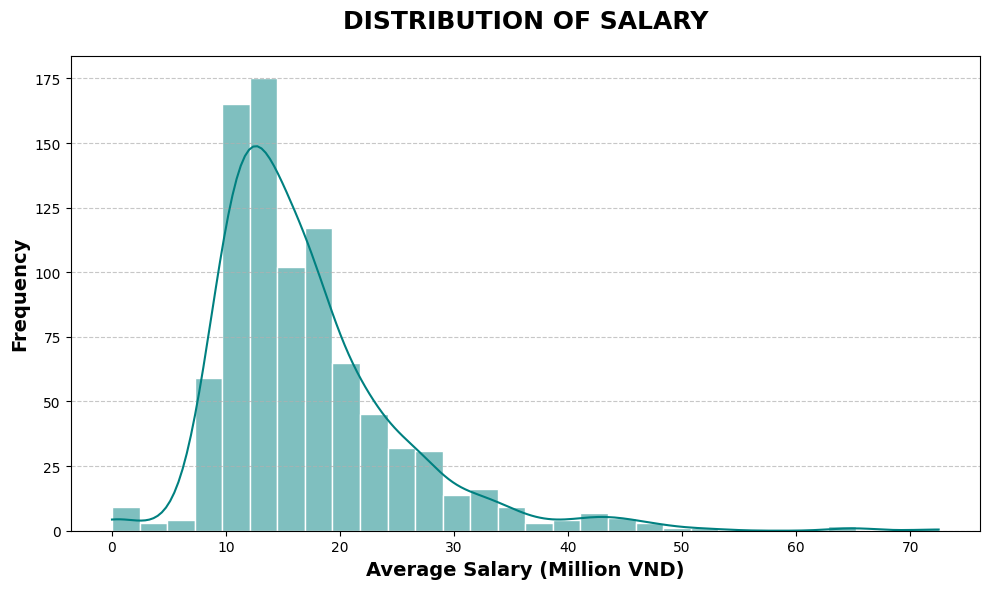

In [ ]:
#Figure 3.3. Distribution of Average Salary
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_avg']/1e6, kde=True, color='teal', bins=30, edgecolor='white')

plt.title('DISTRIBUTION OF SALARY', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Average Salary (Million VND)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

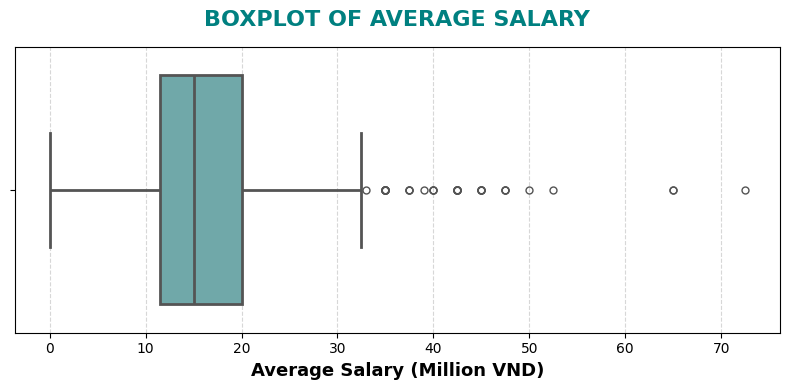

In [ ]:
#Figure 3.4. Boxplot of Average Salary
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['salary_avg']/1e6,
    color='#66b2b2',
    linewidth=2,
    fliersize=5
)

plt.title('BOXPLOT OF AVERAGE SALARY', fontsize=16, fontweight='bold',pad=15, color = 'teal')
plt.xlabel('Average Salary (Million VND)', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

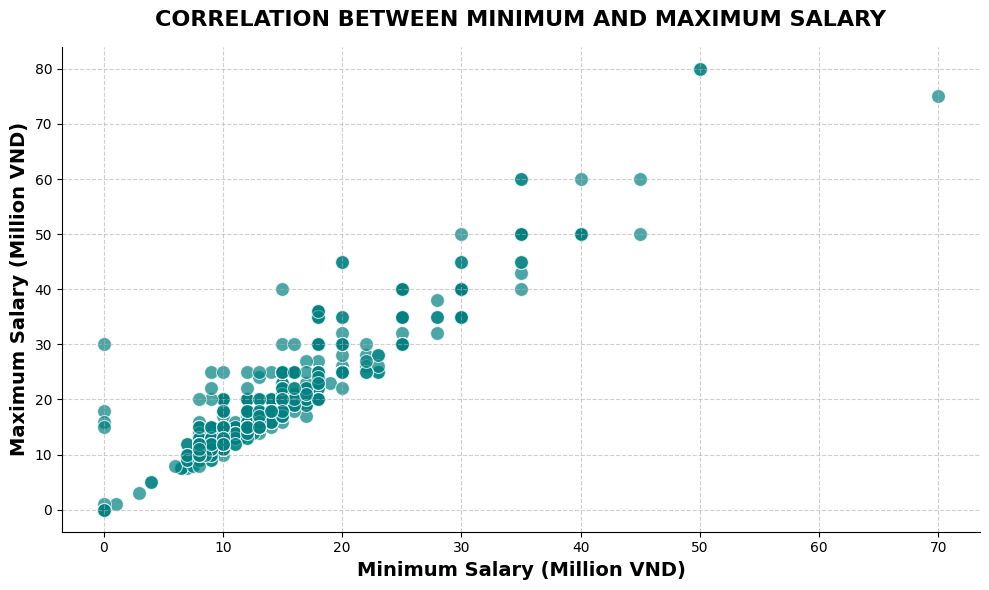

In [ ]:
#Figure 3.5. Salary Range Relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['salary_min']/1e6, y=df['salary_max']/1e6,
                data=df, s=100, alpha=0.7, color='teal')

plt.title('CORRELATION BETWEEN MINIMUM AND MAXIMUM SALARY', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Minimum Salary (Million VND)', fontsize=14, fontweight='bold' )
plt.ylabel('Maximum Salary (Million VND)', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

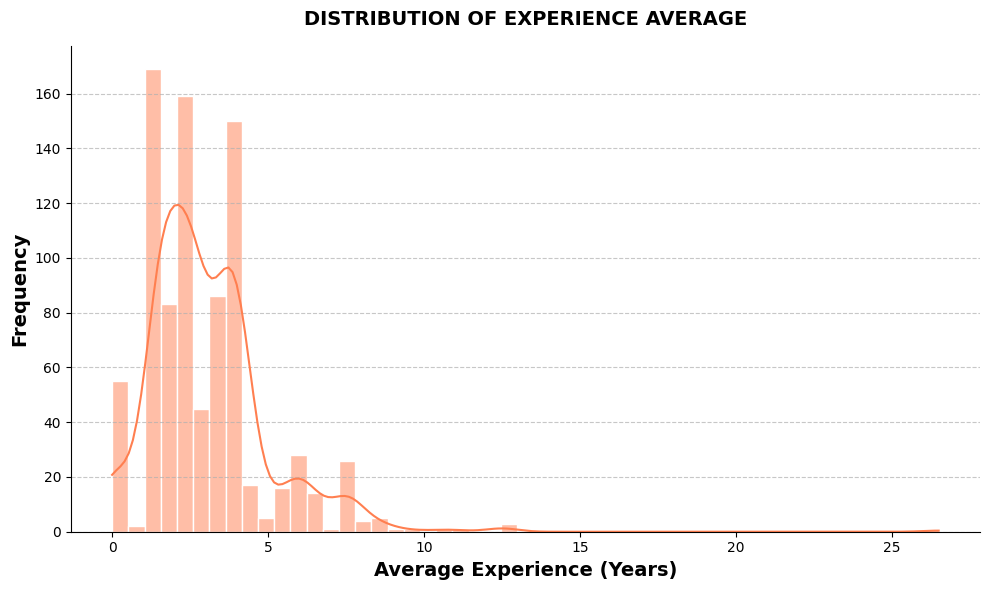

In [ ]:
#Figure 3.6. Distribution of Average Experience
plt.figure(figsize=(10, 6))

sns.histplot(df['experience_avg'], kde=True, color='coral', edgecolor='white')

plt.title('DISTRIBUTION OF EXPERIENCE AVERAGE', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Average Experience (Years)', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

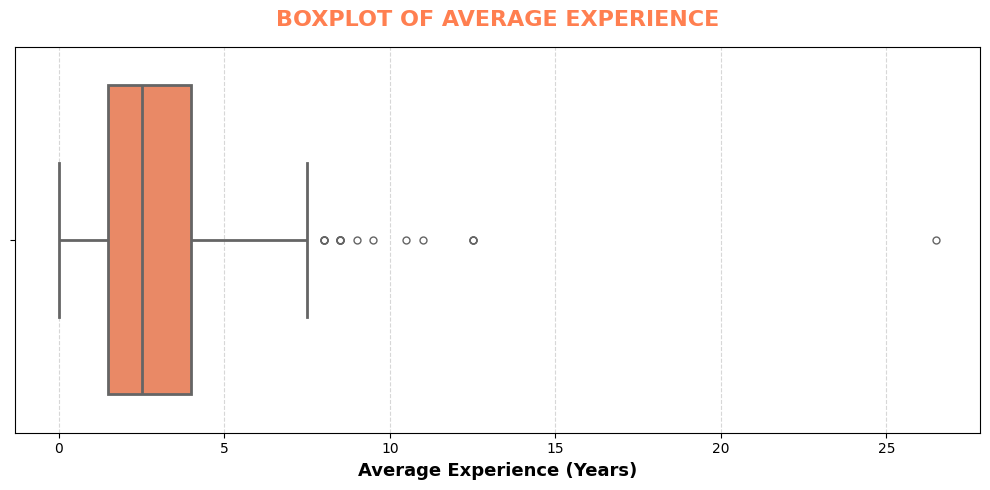

In [ ]:
#Figure 3.7. Boxplot of Average Experience
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df['experience_avg'],
    color='coral',
    linewidth=2,
    fliersize=5
)

plt.title('BOXPLOT OF AVERAGE EXPERIENCE', fontsize=16, fontweight='bold',pad=15, color = 'coral')
plt.xlabel('Average Experience (Years)', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

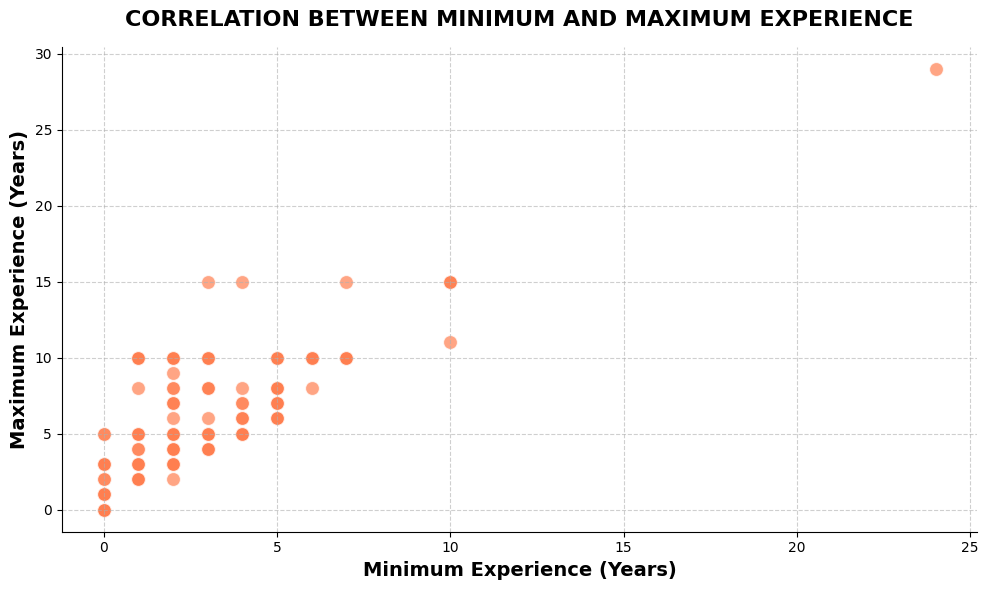

In [ ]:
#Figure 3.8. Experience Range Relationship
plt.figure(figsize=(10, 6))

sns.scatterplot(x='experience_min', y='experience_max',
                data=df, s=100, alpha=0.7, color='coral')

plt.title('CORRELATION BETWEEN MINIMUM AND MAXIMUM EXPERIENCE', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Minimum Experience (Years)', fontsize=14, fontweight='bold')
plt.ylabel('Maximum Experience (Years)', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#Figure 3.9. Number of Jobs by Job Level
plt.figure(figsize=(12, 6))
level_order = ['Manager', 'Senior', 'Junior', 'Fresher', 'Intern']
existing_levels = [l for l in level_order if l in df['job_level'].unique()]

sns.countplot(x='job_level', data=df, order=existing_levels,
              hue='job_level', palette='viridis', legend=False)

plt.title('Job Level Distribution'.upper(), fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Job Level', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width()/2., height),
                           ha='center', va='baseline', fontsize=11, fontweight='bold',
                           xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

NameError: name 'plt' is not defined

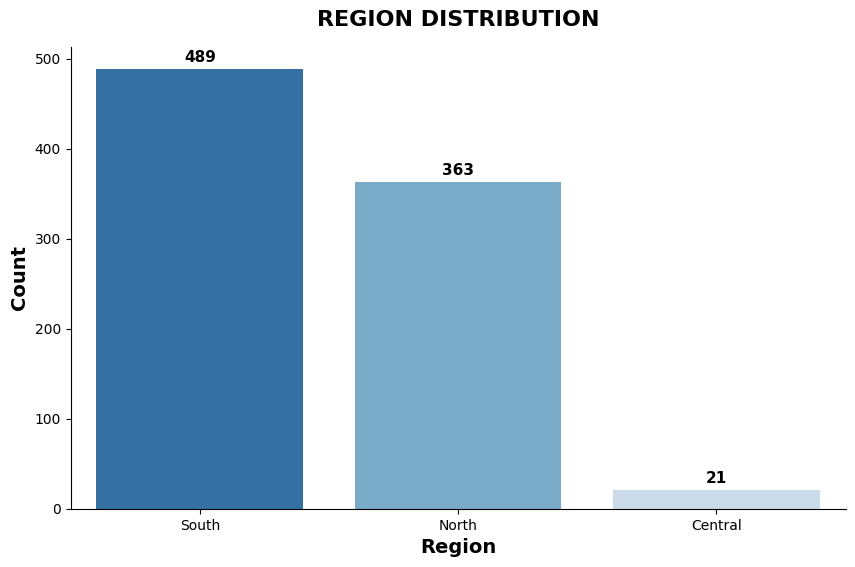

In [ ]:
#Figure 3.10. Number of Jobs by Region
plt.figure(figsize=(10, 6))
region_order = df['region'].value_counts().index

sns.countplot(x='region', data=df, order=region_order, hue='region', palette='Blues_r', legend=False)

plt.title('Region Distribution'.upper(), fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.show()

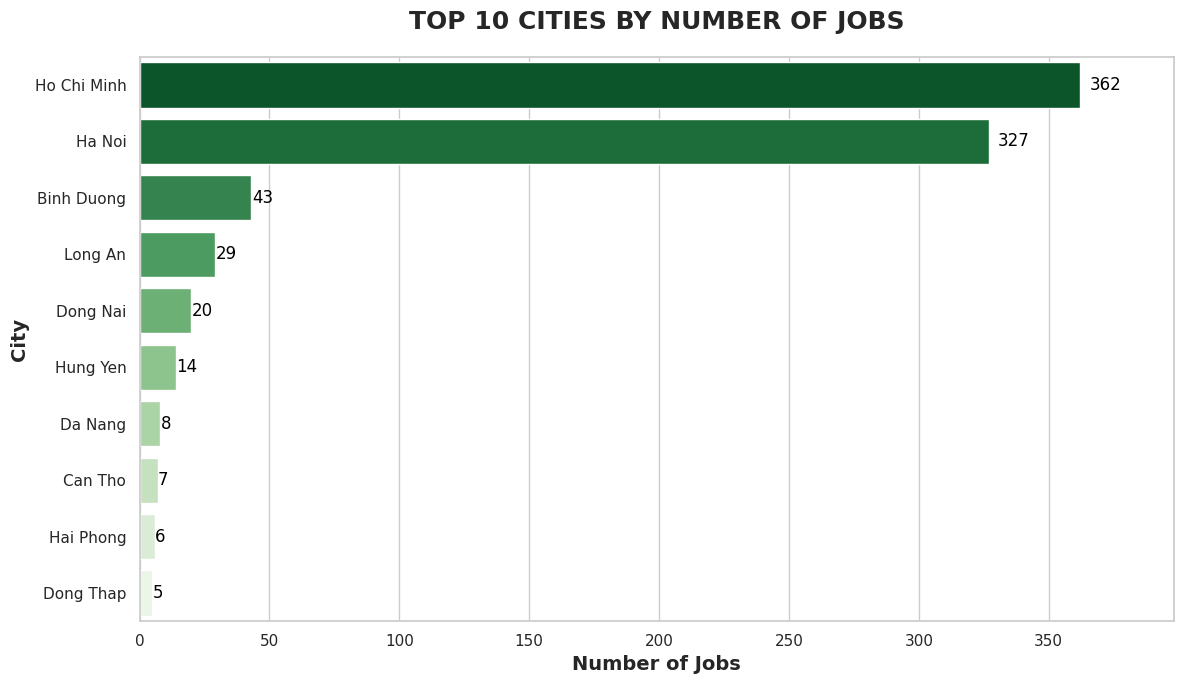

In [ ]:
#Figure 3.11. Top 10 Cities with the Most Job Postings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
city_counts = df['location_list'].value_counts().head(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(x=city_counts.values, y=city_counts.index, palette='Greens_r', hue=city_counts.index, legend=False)

for i, v in enumerate(city_counts.values):
    ax.text(v + (v * 0.01), i, str(int(v)),
            color='black', va='center', fontsize=12)

plt.title('Top 10 Cities by Number of Jobs'.upper(), fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Jobs', fontsize=14, fontweight='bold')
plt.ylabel('City', fontsize=14, fontweight='bold')
plt.xlim(0, max(city_counts.values) * 1.1)

plt.tight_layout()
plt.show()

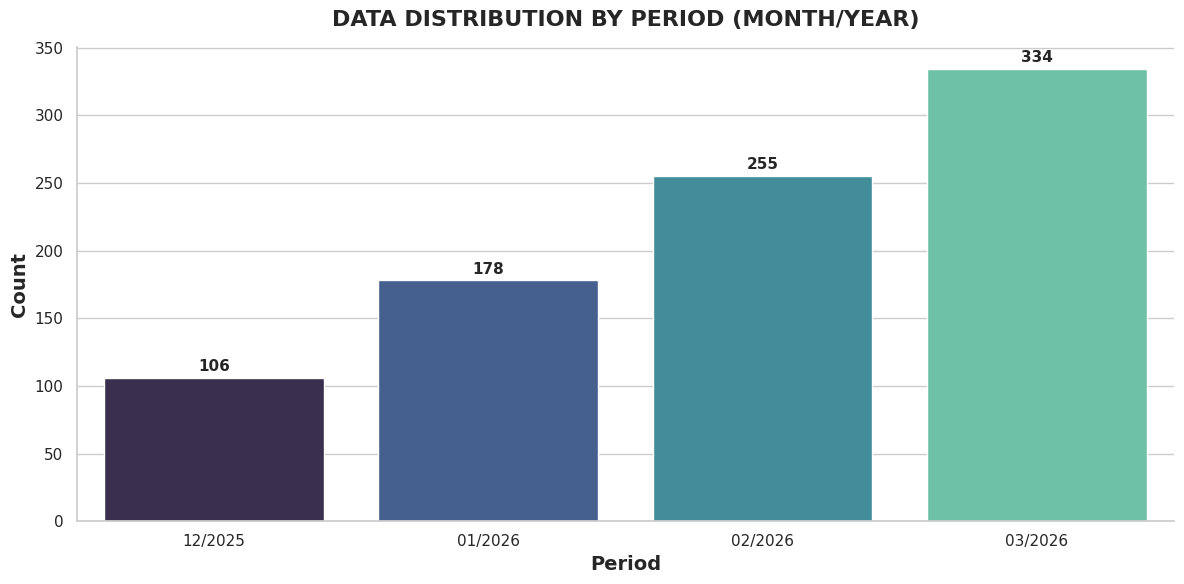

In [ ]:
#Figure 3.12. Number of Jobs by Period
df = df.sort_values(['year', 'month'])
df['period'] = df['month'].astype(str).str.zfill(2) + '/' + df['year'].astype(str)
plt.figure(figsize=(12, 6))
period_order = df['period'].unique()

sns.countplot(
    x='period',
    data=df,
    order=period_order,
    hue='period',
    palette='mako',
    legend=False
)

plt.title('Data Distribution by Period (Month/Year)'.upper(), fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Period', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}',
                           (p.get_x() + p.get_width() / 2., height),
                           ha='center', va='baseline', fontsize=11,
                           fontweight='bold', xytext=(0, 5),
                           textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

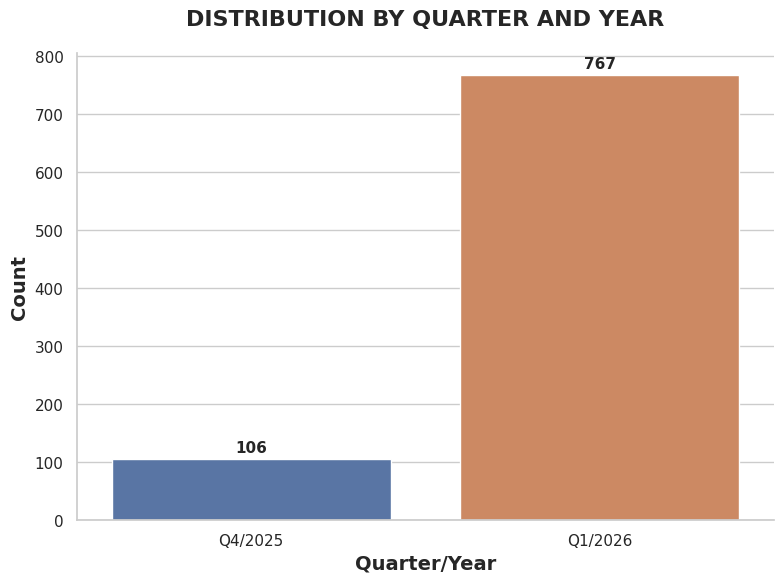

In [ ]:
#Figure 3.13. Number of Jobs by Quarter/Year
df = df.sort_values(['year', 'quarter'])
df['q_period'] = 'Q' + df['quarter'].astype(str) + '/' + df['year'].astype(str)
q_order = df['q_period'].unique()

plt.figure(figsize=(8, 6))

ax = sns.countplot(
    x='q_period',
    data=df,
    order=q_order,
    hue='q_period',
    legend=False
)

plt.title('Distribution by Quarter and Year'.upper(), fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Quarter/Year', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='baseline',
                    fontsize=11, fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

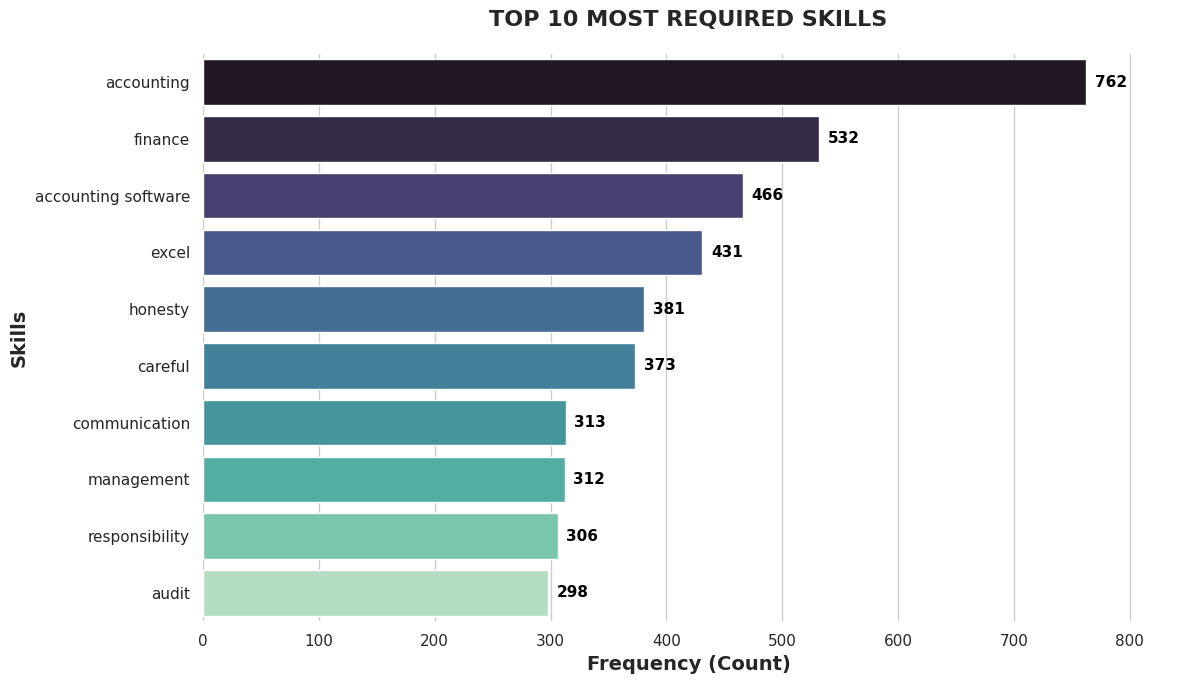

In [ ]:
##Figure 3.14. Top 10 Most In-Demand Skills
skill_cols = [
    'accounting', 'reporting','finance','management','monitoring',
    'inspection','english','accounting software','excel','misa','fast',
    'sap','erp','accounts payable','reconciliation','audit',
    'inventory checking','tax finalization','cash inflow/outflow',
    'analysis','communication','teamwork','honesty','careful',
    'responsibility','proactiveness','work under pressure','detail oriented'
]
skill_sum = df[skill_cols].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=skill_sum.values, y=skill_sum.index, hue=skill_sum.index, palette='mako', legend=False)

for i, v in enumerate(skill_sum.values):
    ax.text(v + (max(skill_sum.values) * 0.01), i, f'{int(v)}',
            va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Top 10 Most Required Skills'.upper(), fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency (Count)', fontsize=14, fontweight='bold')
plt.ylabel('Skills', fontsize=14, fontweight='bold')
plt.xlim(0, max(skill_sum.values) * 1.1)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

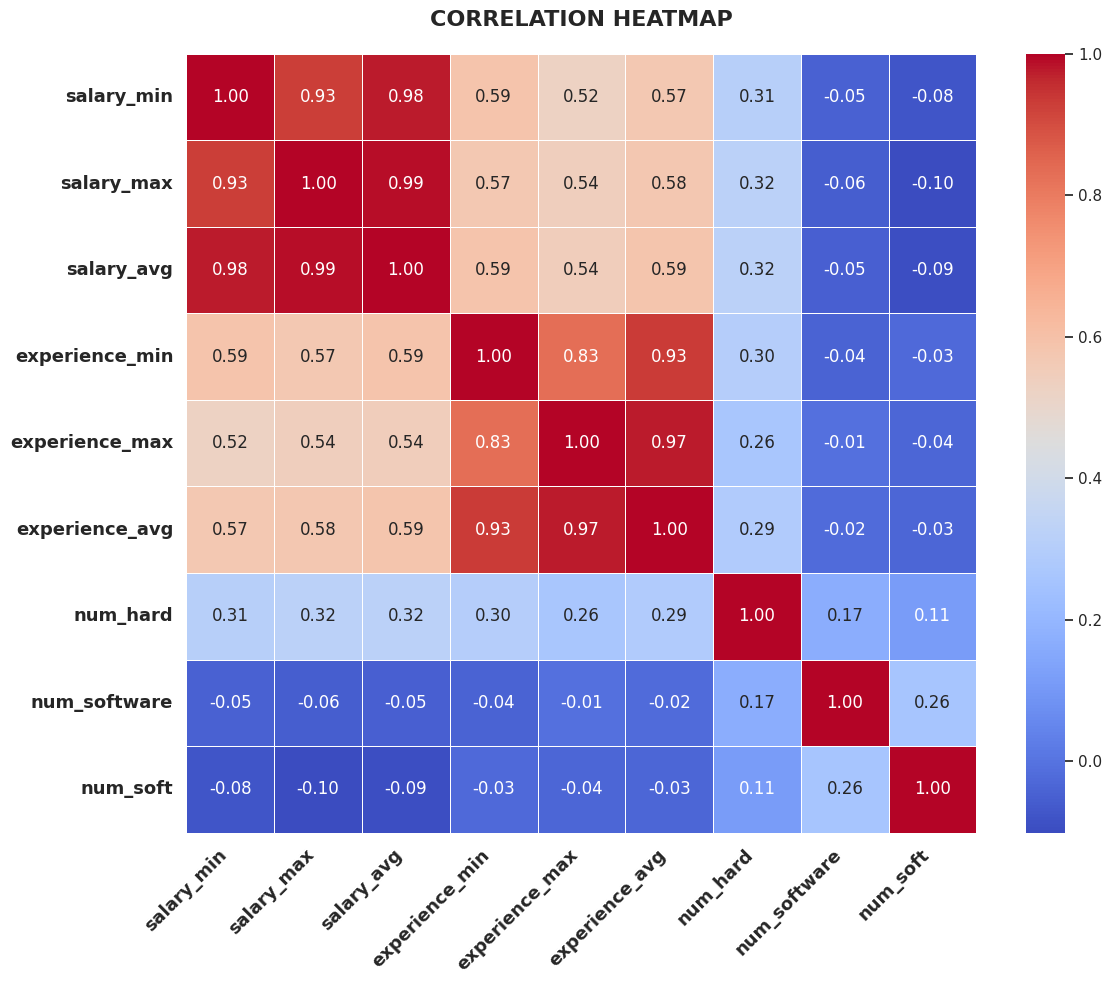

In [ ]:
#Figure 3.15. Correlation Heatmap of Numerical Variables
num_cols = [
    'salary_min', 'salary_max', 'salary_avg',
    'experience_min', 'experience_max', 'experience_avg',
    'num_hard', 'num_software', 'num_soft'
]

plt.figure(figsize=(12, 10))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap'.upper(), fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=13, fontweight='bold')
plt.yticks(rotation=0, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
print("Salary skewness:", df['salary_avg'].skew())
print("Experience skewness:", df['experience_avg'].skew())

Salary skewness: 1.9247065416996796
Experience skewness: 2.790556714647649


In [ ]:
#To remove variables that are unnecessary for analysis
columns_to_remove = [
    'job_title', 'salary_string', 'location', 'address',
    'job_active_date', 'link', 'job_description',
    'requirements', 'jd+req', 'skill'
]
df = df.drop(columns=columns_to_remove, errors='ignore')

print("Remaining columns in DataFrame:")
print(df.columns.tolist())

df.info()

Remaining columns in DataFrame:
['job_id', 'experience_min', 'experience_max', 'salary_min', 'salary_max', 'salary_avg', 'experience_avg', 'job_level', 'year', 'month', 'quarter', 'day', 'location_list', 'region', 'accounting', 'reporting', 'finance', 'management', 'monitoring', 'inspection', 'english', 'accounting software', 'excel', 'misa', 'fast', 'sap', 'erp', 'accounts payable', 'reconciliation', 'audit', 'inventory checking', 'tax finalization', 'cash inflow/outflow', 'analysis', 'communication', 'teamwork', 'honesty', 'careful', 'responsibility', 'proactiveness', 'work under pressure', 'detail oriented', 'num_hard', 'num_software', 'num_soft', 'period', 'q_period']
<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 6 to 872
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               873 non-null    object 
 1   experience_min       873 non-null    float64
 2   experience_max

In [ ]:
from google.colab import files
df.to_csv('Tasks WDA - ANALYSIS.csv', index=False, encoding='utf-8-sig')
files.download('Tasks WDA - ANALYSIS.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>